In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f1(t, y):
    return (1 + 4*t) - y

def exact1(t):
    return 4*t - 3 + 4*np.exp(-t)

In [3]:
def euler_method(f, t0, y0, h, tend):
    n = int(round((tend - t0) / h))
    t = np.zeros(n+1)
    y = np.zeros(n+1)
    t[0] = t0
    y[0] = y0
    for i in range(n):
        y[i+1] = y[i] + h * f(t[i], y[i])
        t[i+1] = t[i] + h
    return t, y

In [4]:
def midpoint_method(f, t0, y0, t_end, h):
    steps = int(round((t_end - t0) / h))
    t_values = np.zeros(steps + 1)
    y_values = np.zeros(steps + 1)
    t_values[0] = t0
    y_values[0] = y0
    
    for i in range(steps):
        t = t_values[i]
        y = y_values[i]
        
        k1 = f(t, y)
        t_mid = t + h / 2
        y_mid = y + (h / 2) * k1
        k2 = f(t_mid, y_mid)
        
        y_values[i+1] = y + h * k2
        t_values[i+1] = t + h
        
    return t_values, y_values

In [5]:
def heun_method(f, t0, y0, h, tend):
    n = int(round((tend - t0) / h))
    t = np.zeros(n+1)
    y = np.zeros(n+1)
    t[0] = t0
    y[0] = y0
    for i in range(n):
        k1 = f(t[i], y[i])
        y_pred = y[i] + h * k1
        k2 = f(t[i] + h, y_pred)
        y[i+1] = y[i] + (h / 2.0) * (k1 + k2)
        t[i+1] = t[i] + h
    return t, y

In [6]:
h_list1 = [0.5, 0.25, 0.1, 0.01, 0.001]
print_h_list1 = [0.5, 0.25, 0.1]
t0, y0, tend = 0, 1, 5

euler_results1 = {}
heun_results1 = {}
midpoint_results1 = {}

for h in h_list1:
    te, ye = euler_method(f1, t0, y0, h, tend)
    th, yh = heun_method(f1, t0, y0, h, tend)
    t_mid, y_mid = midpoint_method(f1, t0, y0, h, tend) 
    
    yexact_e = exact1(te)
    yexact_h = exact1(th)
    yexact_mid = exact1(t_mid)
    
    err_e = np.abs(yexact_e - ye)
    err_h = np.abs(yexact_h - yh)
    err_mid = np.abs(yexact_mid - y_mid)
    
    euler_results1[h] = (te, ye, yexact_e, err_e)
    heun_results1[h] = (th, yh, yexact_h, err_h)
    midpoint_results1[h] = (t_mid, y_mid, yexact_mid, err_mid)

In [7]:
for h in print_h_list1:
    te, ye, yexact_e, err_e = euler_results1[h]
    print(f"\n--- Euler Method Table (h = {h}) ---")
    print(f"{'t':>6}{'Euler y':>15}{'Exact y':>15}{'Error':>15}")
    for i in range(len(te)):
        print(f"{te[i]:6.3f}{ye[i]:15.6f}{yexact_e[i]:15.6f}{err_e[i]:15.6f}")

for h in print_h_list1:
    th, yh, yexact_h, err_h = heun_results1[h]
    print(f"\n--- Heun Method Table (h = {h}) ---")
    print(f"{'t':>6}{'Heun y':>15}{'Exact y':>15}{'Error':>15}")
    for i in range(len(th)):
        print(f"{th[i]:6.3f}{yh[i]:15.6f}{yexact_h[i]:15.6f}{err_h[i]:15.6f}")

for h in print_h_list1:
    t_mid, y_mid, yexact_mid, err_mid = midpoint_results1[h]
    print(f"\n--- Midpoint Method Table (h = {h}) ---")
    print(f"{'t':>6}{'Midpoint y':>15}{'Exact y':>15}{'Error':>15}")
    for i in range(len(t_mid)):
        print(f"{t_mid[i]:6.3f}{y_mid[i]:15.6f}{yexact_mid[i]:15.6f}{err_mid[i]:15.6f}")


--- Euler Method Table (h = 0.5) ---
     t        Euler y        Exact y          Error
 0.000       1.000000       1.000000       0.000000
 0.500       1.000000       1.426123       0.426123
 1.000       2.000000       2.471518       0.471518
 1.500       3.500000       3.892521       0.392521
 2.000       5.250000       5.541341       0.291341
 2.500       7.125000       7.328340       0.203340
 3.000       9.062500       9.199148       0.136648
 3.500      11.031250      11.120790       0.089540
 4.000      13.015625      13.073263       0.057638
 4.500      15.007812      15.044436       0.036623
 5.000      17.003906      17.026952       0.023046

--- Euler Method Table (h = 0.25) ---
     t        Euler y        Exact y          Error
 0.000       1.000000       1.000000       0.000000
 0.250       1.000000       1.115203       0.115203
 0.500       1.250000       1.426123       0.176123
 0.750       1.687500       1.889466       0.201966
 1.000       2.265625       2.471518   

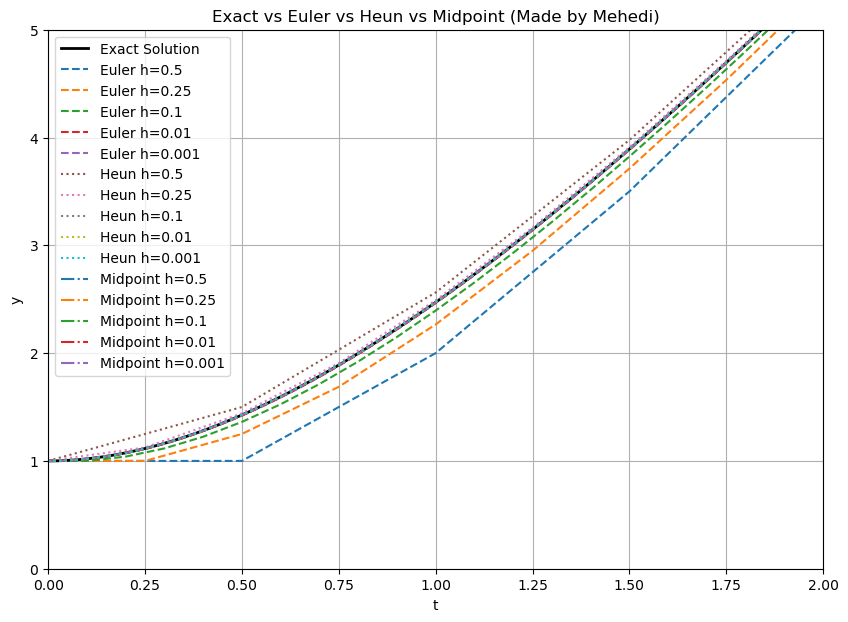

In [8]:
plt.figure(figsize=(10, 7))
tt = np.linspace(t0, tend, 500)
plt.plot(tt, exact1(tt), 'k-', linewidth=2, label='Exact Solution')

for h in h_list1:
    te, ye, _, _ = euler_results1[h]
    plt.plot(te, ye, '--', label=f'Euler h={h}')

for h in h_list1:
    th, yh, _, _ = heun_results1[h]
    plt.plot(th, yh, ':', label=f'Heun h={h}')

for h in h_list1:
    t_mid, y_mid, _, _ = midpoint_results1[h]
    plt.plot(t_mid, y_mid, '-.', label=f'Midpoint h={h}')

plt.xlabel('t')
plt.ylabel('y')
plt.title('Exact vs Euler vs Heun vs Midpoint (Made by Mehedi)')
plt.xlim(0, 2)
plt.ylim(0, 5)
plt.legend()
plt.grid(True)
plt.show()